# EDA: Time Series Analysis: IBM vs Walmart (5 Years)
### Moving Average Forecasting & Decomposition

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Data source / Fuente:** Yahoo Finance via `yfinance` — 5 years daily prices, auto-downloaded

**Objective / Objetivo:**  
EN · Explore and compare IBM and Walmart stock price series over 5 years. Apply STL decomposition, ACF/PACF analysis, Dickey-Fuller stationarity test, and simple moving average (SMA-5, SMA-20) forecasting. Critically evaluate whether SMA is a reliable predictive tool.

ES · Explorar y comparar las series de precios de IBM y Walmart durante 5 años. Aplicar descomposición STL, análisis ACF/PACF, prueba de estacionariedad Dickey-Fuller y pronóstico con promedios móviles (SMA-5, SMA-20). Evaluar críticamente si SMA es una herramienta predictiva confiable.

**Key finding / Hallazgo clave:**  
SMA-5 achieves MAPE of 1.97% (IBM) and 1.51% (WMT) — deceptively low because moving averages simply track yesterday's price (random walk behavior), not true predictive power.

**Techniques / Técnicas:** STL Decomposition · ACF · PACF · Dickey-Fuller · SMA-5 · SMA-20 · MAE · MAPE  
**Libraries / Librerías:** `yfinance` · `pandas` · `numpy` · `statsmodels` · `matplotlib` · `seaborn`

> **Note / Nota:** Data downloads automatically from Yahoo Finance each time the notebook runs. No local files needed.

---

## 1. Importación de librerías

Se usa `yfinance` para descargar los precios históricos directamente desde Yahoo Finance, `pandas`/`numpy` para el manejo de datos, `matplotlib`/`seaborn` para las gráficas y `statsmodels` para la descomposición, los correlogramas (ACF/PACF) y la prueba de Dickey-Fuller.

In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")

## 2. Descarga de datos históricos (5 años, frecuencia diaria)

### Nomenclatura de la serie de tiempo

Al descargar datos con `yfinance` se obtiene, para cada día hábil bursátil, las siguientes columnas:

| Columna | Significado |
|---|---|
| **Open** | Precio de apertura del día |
| **High** | Precio máximo alcanzado en el día |
| **Low** | Precio mínimo alcanzado en el día |
| **Close** | Precio de cierre del día |
| **Adj Close** | Precio de cierre ajustado por dividendos y splits (el más adecuado para análisis de largo plazo) |
| **Volume** | Número de acciones negociadas ese día |

Se trabaja principalmente con **`Close`** (ajustado automáticamente por `yfinance` con `auto_adjust=True`), ya que representa el valor de la acción al cierre de cada sesión y es la variable convencional para el análisis de series de tiempo financieras.

El índice de la serie es la **fecha**, con una frecuencia aproximadamente diaria, solo días hábiles bursátiles, de ahí los "huecos" en fines de semana y días festivos. Es importante a tener esto en cuenta en la nomenclatura de series de tiempo financieras ya que no son estrictamente equiespaciadas en el calendario.

In [8]:
tickers = ["IBM", "WMT"]  # IBM y Walmart

data = yf.download(tickers, period="5y", interval="1d", auto_adjust=True, group_by="ticker")
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker            WMT                                                    IBM  \
Price            Open       High        Low      Close    Volume        Open   
Date                                                                           
2021-07-22  44.134638  44.444235  44.031442  44.178421  13013400  111.367862   
2021-07-23  44.256594  44.631863  44.097107  44.541172  15947400  110.817559   
2021-07-26  44.519282  44.988367  44.237828  44.603714  18517200  111.155564   
2021-07-27  44.719429  44.719429  44.394195  44.606846  15395700  112.051827   
2021-07-28  44.556804  44.797602  44.300373  44.425461  14071500  112.429151   

Ticker                                                   
Price             High         Low       Close   Volume  
Date                                                     
2021-07-22  111.485785  110.385163  110.621010  3466653  
2021-07-23  111.399308  110.322276  111.116295  4680013  
2021-07-26  112.421288  110.951162  112.240463  4441630  
2021-07-27  112.924470  111.320697  112.224785  3281302  
2021-07-28  112.499908  111.352107  111.454308  2660815

In [9]:
# Extraer únicamente el precio de cierre (Close) de cada empresa en un DataFrame ordenado
close = pd.DataFrame({
    "IBM": data["IBM"]["Close"],
    "WMT": data["WMT"]["Close"]
}).dropna()

close.index.name = "Fecha"
print(f"Rango de fechas: {close.index.min().date()} a {close.index.max().date()}")
print(f"Número de observaciones: {len(close)}")
close.head()

Rango de fechas: 2021-07-22 a 2026-07-21
Número de observaciones: 1254


,IBM,WMT
Fecha,,
2021-07-22,110.621010,44.178421
2021-07-23,111.116295,44.541172
2021-07-26,112.240463,44.603714
2021-07-27,112.224785,44.606846
2021-07-28,111.454308,44.425461


In [10]:
close.describe()

,IBM,WMT
count,1254.000000,1254.000000
mean,175.217187,69.536538
std,64.790290,27.933798
min,97.615479,37.557854
25%,116.147575,46.160076
50%,154.632324,53.546928
75%,235.415821,95.044935
max,329.230011,134.199997


## 3. Visualización de tendencias: precio de cierre histórico

Se usan dos ejes (`twinx`) porque IBM y Walmart cotizan en rangos de precio distintos; graficarlas en el mismo eje distorsionaría la comparación visual de sus tendencias

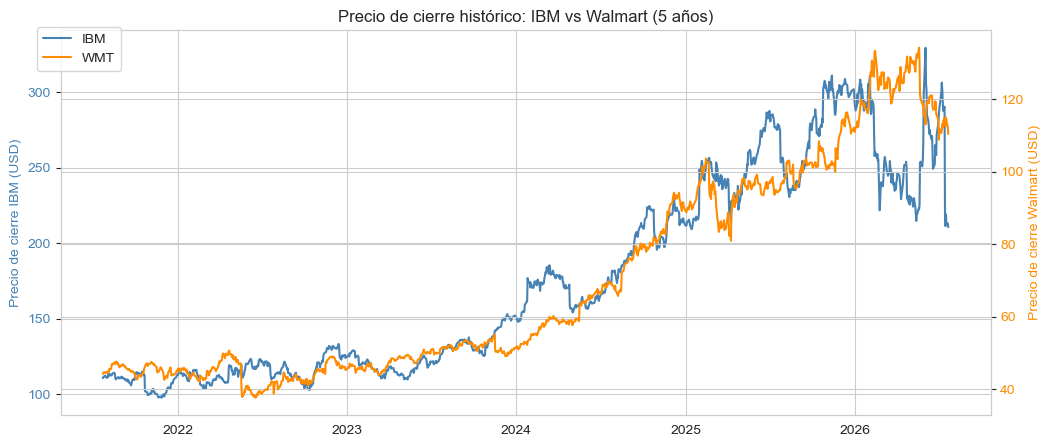

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(close.index, close["IBM"], label="IBM", color="steelblue")
ax.set_ylabel("Precio de cierre IBM (USD)", color="steelblue")
ax.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax.twinx()
ax2.plot(close.index, close["WMT"], label="WMT", color="darkorange")
ax2.set_ylabel("Precio de cierre Walmart (USD)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax.set_title("Precio de cierre histórico: IBM vs Walmart (5 años)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

## 4. Encontrar si existe correlación entre los precios de las acciones de ambas empresas

Se responde de dos formas:

1. **Correlación de los precios en niveles** (`Close` vs `Close`): útil para ver si ambas series se han movido en la misma dirección a largo plazo, pero puede ser engañosa (correlación espuria) porque casi cualquier par de series con tendencia creciente en el tiempo mostrará alta correlación aunque no exista relación causal real.
2. **Correlación de los rendimientos diarios** (`% change`): es la forma estadísticamente más correcta de medir co-movimiento entre dos activos, porque los rendimientos son (aproximadamente) estacionarios, a diferencia de los precios en niveles.

Se usa el **coeficiente de correlación de Pearson**, que mide la fuerza y dirección de una relación lineal entre dos variables, con valores entre -1 (correlación negativa perfecta) y +1 (correlación positiva perfecta); 0 indica ausencia de relación lineal.

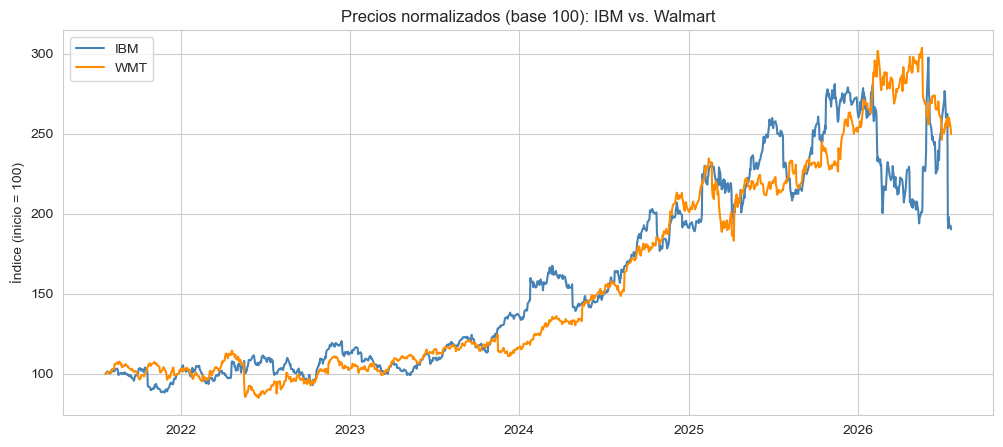

In [30]:
# Normalizar los precios a base 100 para comparar visualmente su comportamiento relativo
normalized = close / close.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(normalized.index, normalized["IBM"], label="IBM", color="steelblue")
ax.plot(normalized.index, normalized["WMT"], label="WMT", color="darkorange")
ax.set_title("Precios normalizados (base 100): IBM vs. Walmart")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()
plt.show()

In [15]:
# Correlación de los precios en niveles
corr_niveles = close["IBM"].corr(close["WMT"])
print(f"Correlación de Pearson (precios en niveles): {corr_niveles:.4f}")

# Correlación de los rendimientos diarios (% de cambio)
returns = close.pct_change().dropna()
corr_returns = returns["IBM"].corr(returns["WMT"])
print(f"Correlación de Pearson (rendimientos diarios): {corr_returns:.4f}")

Correlación de Pearson (precios en niveles): 0.9327
Correlación de Pearson (rendimientos diarios): 0.1014


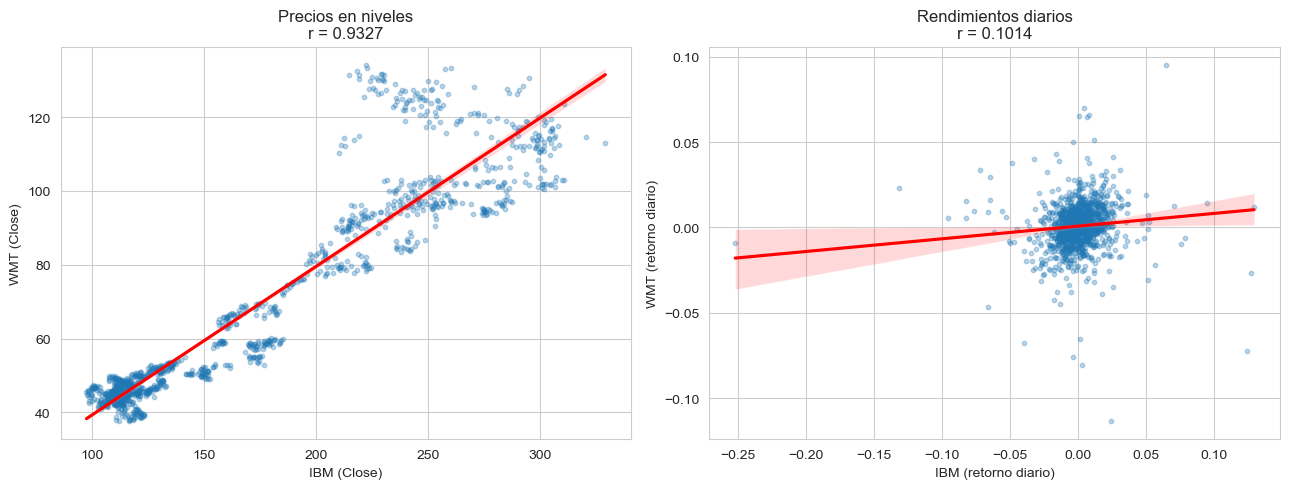

In [56]:
# Visualización de correlaciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(x=close["IBM"], y=close["WMT"], ax=axes[0], scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"})
axes[0].set_title(f"Precios en niveles\nr = {corr_niveles:.4f}")
axes[0].set_xlabel("IBM (Close)")
axes[0].set_ylabel("WMT (Close)")

sns.regplot(x=returns["IBM"], y=returns["WMT"], ax=axes[1], scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"})
axes[1].set_title(f"Rendimientos diarios\nr = {corr_returns:.4f}")
axes[1].set_xlabel("IBM (retorno diario)")
axes[1].set_ylabel("WMT (retorno diario)")

plt.tight_layout()
plt.show()

### Interpretación de las correlaciones obtenidas

- **Correlación en niveles (r = 0.9327):** es muy alta y positiva. El scatter de la izquierda lo confirma ya que los puntos siguen una línea prácticamente recta ascendente. Sin embargo, esto no significa que IBM y Walmart estén fundamentalmente ligadas como negocios, ya qye ambas series comparten una tendencia de largo plazo creciente (visible en las gráficas de precio), y dos series con tendencia común casi siempre producen una correlación alta aunque no exista relación causal real entre ellas. Este es el ejemplo clásico de **correlación espuria por no-estacionariedad**, se están correlacionando dos "caminatas aleatorias con tendencia", no el comportamiento genuino día a día de ambas acciones.

- **Correlación de rendimientos (r = 0.1014):** es positiva pero muy débil, incluso más baja de lo que se suele observar entre dos acciones grandes del mismo mercado (típicamente 0.2–0.5). El scatter de la derecha lo muestra claramente con la nube de puntos que es prácticamente circular, sin una relación lineal visible, y la mayoría de las observaciones se concentran muy cerca de (0, 0). Esto indica que, **día a día, el movimiento porcentual de IBM casi no tiene relación lineal con el de Walmart**, o sea, son dos series con dinámicas de corto plazo bastante independientes entre sí. Esto tiene sentido, dado que pertenecen a sectores muy distintos, tecnología/servicios de TI vs retail de consumo básico, y por lo tanto reaccionan a catalizadores distintos.

**Conclusión:** el contraste entre r = 0.9327 (niveles) y r = 0.1014 (rendimientos) muestra que la correlación "alta" entre los precios de IBM y Walmart es en gran medida un artefacto de la tendencia compartida del mercado, no una señal de que ambas acciones se muevan juntas. En términos de comovimiento real (rendimientos diarios), la relación es casi nula, lo que sugiere que combinar IBM y Walmart en un portafolio sí ofrece un beneficio de diversificación considerable, ya que sus fluctuaciones de corto plazo son prácticamente independientes.

## 5. Descomposición de las series y correlogramas

### 5.1 Descomposición

Se descompone cada serie en sus **componentes**:

- **Tendencia (trend):** movimiento de largo plazo de la serie
- **Estacionalidad (seasonal):** patrón que se repite en periodos fijos
- **Residuo (resid):** lo que queda después de remover tendencia y estacionalidad, es el "ruido" o componente irregular

Se usa un modelo **multiplicativo** (`Serie = Tendencia × Estacionalidad × Residuo`), apropiado para precios de acciones porque la magnitud de las fluctuaciones tiende a crecer conforme crece el nivel del precio (a diferencia del modelo aditivo, donde se asume que las fluctuaciones tienen amplitud constante).

Se usa `period=252` (aproximadamente el número de días hábiles bursátiles en un año) para capturar un posible patrón estacional anual.

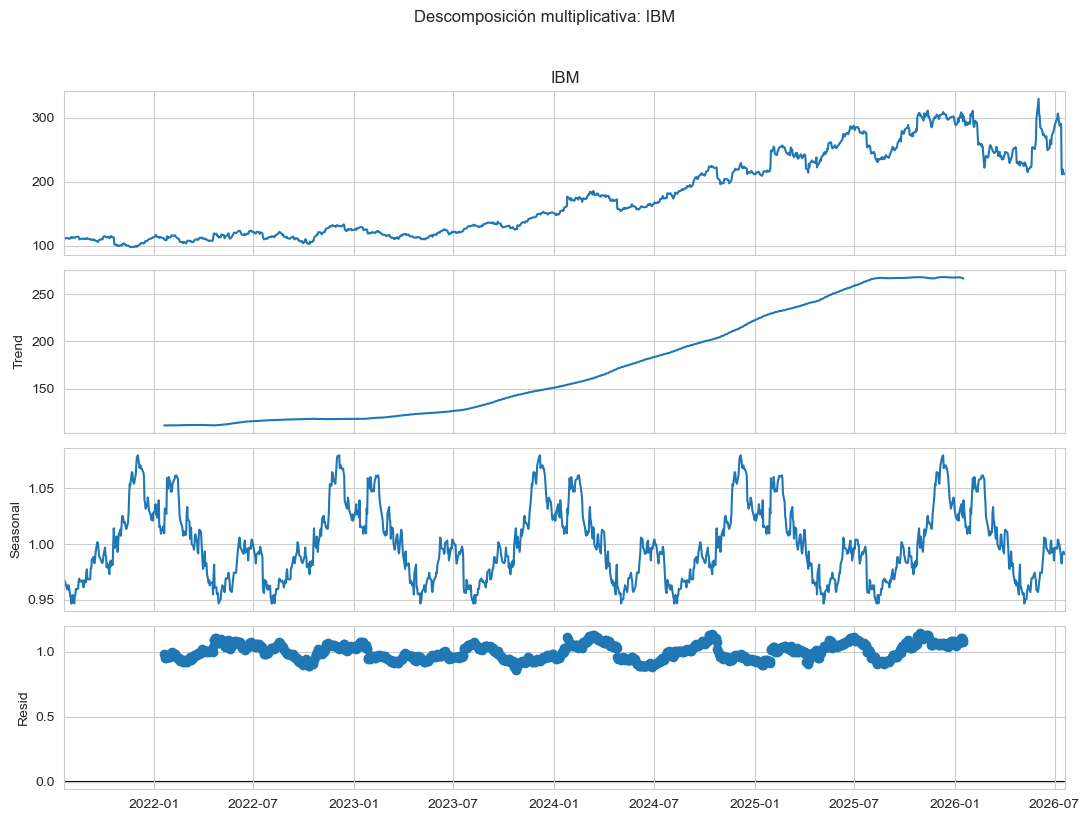

In [26]:
decomp_ibm = seasonal_decompose(close["IBM"], model="multiplicative", period=252)
decomp_wmt = seasonal_decompose(close["WMT"], model="multiplicative", period=252)

fig = decomp_ibm.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa: IBM", y=1.02)
plt.tight_layout()
plt.show()

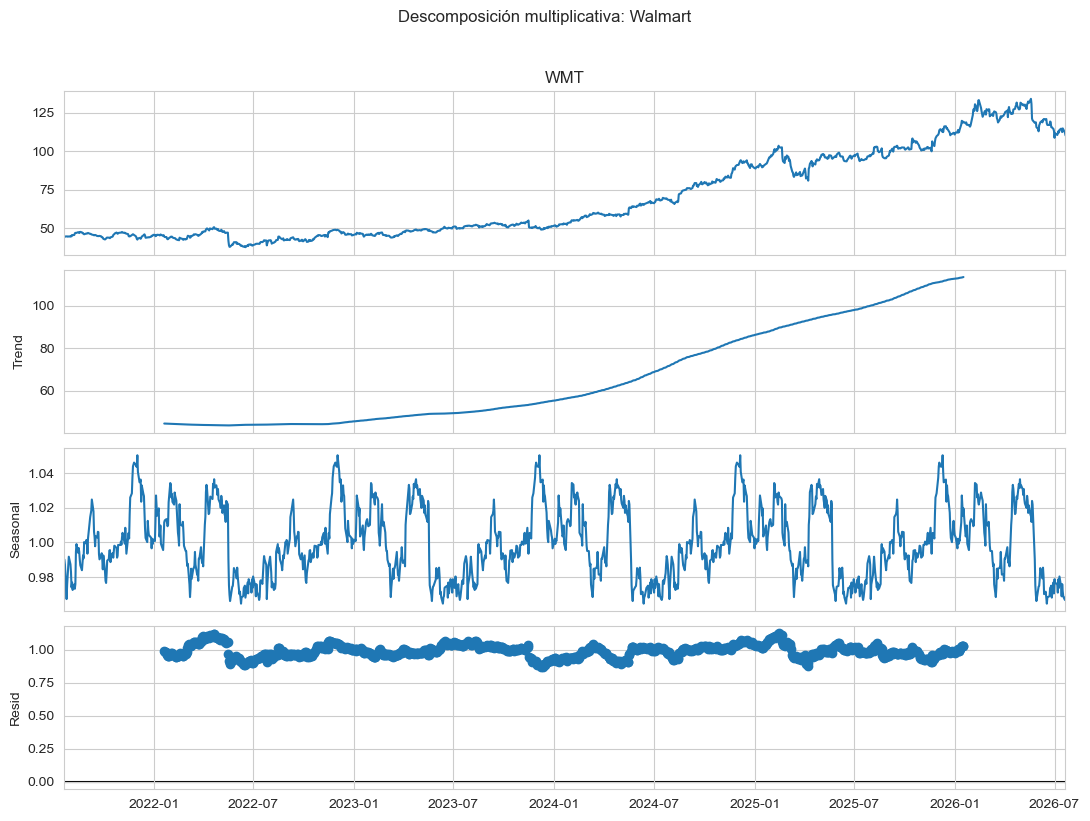

In [24]:
fig = decomp_wmt.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa: Walmart", y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de las descomposiciones obtenidas

- **Tendencia:** en ambas series la tendencia domina por completo la magnitud del movimiento. IBM pasa de ~115 USD (2022) a un pico cercano a ~270 USD (2025-2026), y Walmart pasa de ~45 USD a casi ~120 USD en el mismo periodo. En ambos casos la tendencia se acelera a partir de 2023-2024 ya que la pendiente es mucho más pronunciada en la segunda mitad de la ventana de 5 años que en la primera.
- **Estacionalidad:** el componente estacional es claramente visible y con un patrón regular que se repite cada año (aprox. cada 252 observaciones, como se definió en `period=252`). En IBM oscila entre ~0.95 y ~1.08, y en Walmart entre ~0.97 y ~1.05. En ambos casos el patrón muestra un ciclo anual bastante consistente a lo largo de los 5 años (los picos y valles caen aproximadamente en las mismas épocas del año en cada repetición). Es importante interpretar esto con cautela: en un modelo multiplicativo con `period=252` sobre solo 5 años de datos, parte de este patrón "estacional" puede en realidad estar capturando ciclos de mediano plazo del mercado (por ejemplo, ciclos de resultados trimestrales o ciclos macroeconómicos) más que una estacionalidad calendario genuina como la que tendría, por ejemplo, un negocio con ventas de temporada.
- **Residuo:** es el componente más pequeño de los tres en magnitud relativa ya que fluctúa en un rango angosto, aproximadamente entre 0.8 y 1.15 en ambas series, más estrecho que el rango del componente estacional. Esto indica que, con este nivel de agregación (precio diario a lo largo de 5 años, ventana de suavizado de 252 días), la combinación de tendencia con estacionalidad explica una proporción considerable del movimiento observado, y lo que queda sin explicar (ruido genuino de corto plazo) es comparativamente menor.

### 5.2 Correlogramas (ACF y PACF)

- **ACF (función de autocorrelación):** mide qué tan correlacionada está la serie consigo misma en distintos rezagos (*lags*).
- **PACF (función de autocorrelación parcial):** mide la correlación de un rezago específico, controlando por el efecto de los rezagos intermedios.

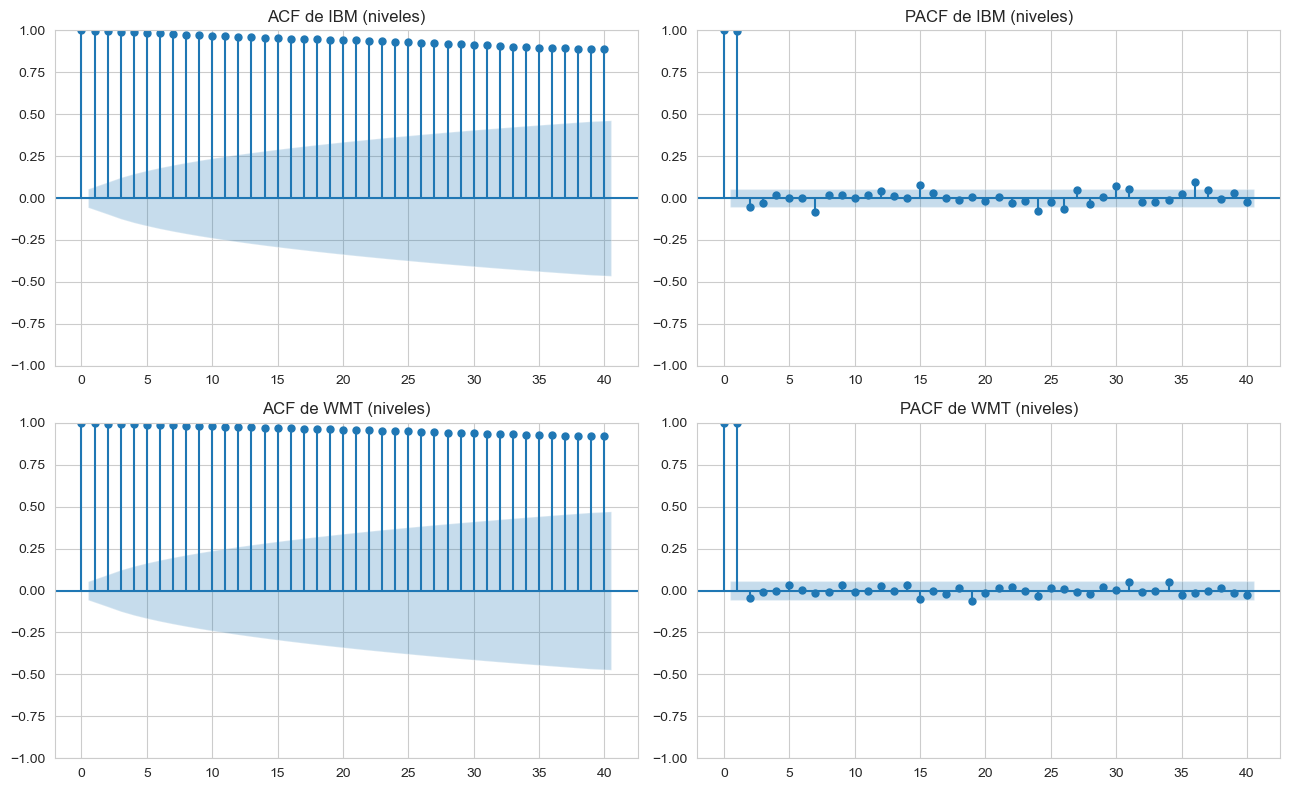

In [35]:
# Correlogramas de los niveles de precios (series originales)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_acf(close["IBM"], lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF de IBM (niveles)")

plot_pacf(close["IBM"], lags=40, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF de IBM (niveles)")

plot_acf(close["WMT"], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF de WMT (niveles)")

plot_pacf(close["WMT"], lags=40, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF de WMT (niveles)")

plt.tight_layout()
plt.show()

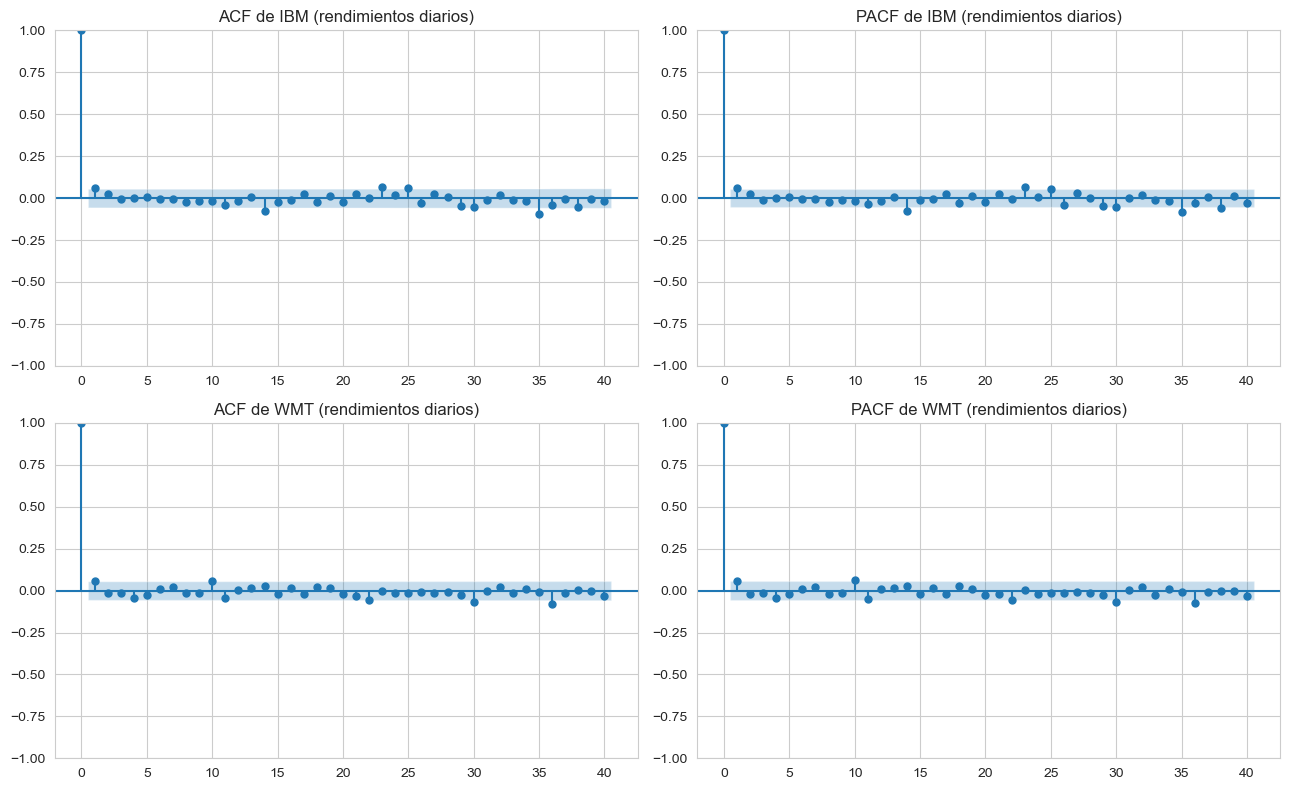

In [36]:
# Correlogramas de los rendimientos diarios (series diferenciadas), para comparar
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_acf(returns["IBM"], lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF de IBM (rendimientos diarios)")

plot_pacf(returns["IBM"], lags=40, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF de IBM (rendimientos diarios)")

plot_acf(returns["WMT"], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF de WMT (rendimientos diarios)")

plot_pacf(returns["WMT"], lags=40, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF de WMT (rendimientos diarios)")

plt.tight_layout()
plt.show()

### Interpretación de los correlogramas obtenidos

- **ACF de los precios en niveles (IBM y WMT):** el comportamiento esperado es de un decaimiento muy lento, con la autocorrelación empezando en 1.0 y manteniéndose por encima de 0.85-0.90 incluso en el rezago 40. Esta es la firma característica de una serie no estacionaria con fuerte componente de tendencia (tipo *random walk* con deriva), es decir, el precio de hoy sigue "arrastrando" información del precio de hace 40 días, simplemente porque ambos pertenecen a la misma trayectoria de tendencia de largo plazo.
- **PACF de los precios en niveles (IBM y WMT):** muestra un pico de 1.0 en el rezago 1, y luego una caída abrupta a valores no significativos (dentro de la banda de confianza) para todos los rezagos posteriores. Esto es consistente con un proceso **AR(1) con coeficiente cercano a 1** (raíz unitaria), esto es, el precio de hoy se explica casi en su totalidad por el precio de ayer, y una vez controlado ese efecto, los rezagos más lejanos no aportan información adicional.
- **ACF/PACF de los rendimientos diarios (IBM y WMT):** aquí el contraste es total respecto a las series en niveles, ya que la autocorrelación cae inmediatamente a valores dentro de la banda de confianza, o sea, prácticamente todos los rezagos, del 1 al 40, están dentro de la zona sombreada de no significancia, con alguna excepción aislada como el rezago ~14 o ~36 que sobresale levemente, que es esperable por azar al probar 40 rezagos. Esto es consistente con la **hipótesis de mercados eficientes**: los rendimientos diarios de IBM y Walmart se comportan de manera muy cercana a ruido blanco, es decir, no hay un patrón autorregresivo explotable de un día para otro.

**En conjunto**, estos correlogramas anticipan exactamente lo que confirma la prueba de Dickey-Fuller a continuación, esto es, los precios en niveles se comportan como una **caminata aleatoria no estacionaria**, mientras que los rendimientos diarios se aproximan mucho a un **proceso estacionario tipo ruido blanco**.

## 6. Prueba de Dickey-Fuller Aumentada (ADF)

La prueba de **Dickey-Fuller Aumentada** contrasta las siguientes hipótesis:

- **H₀ (hipótesis nula):** la serie tiene raíz unitaria → no es estacionaria
- **H₁ (hipótesis alternativa):** la serie no tiene raíz unitaria → es estacionaria

Regla de decisión: 
    
    Si el p-value < 0.05, se rechaza H₀ y se concluye que la serie es estacionaria
    
    Si el p-value ≥ 0.05, no se rechaza H₀ porque no hay evidencia suficiente de estacionariedad

Se aplican las prueba a:
1. Los precios en niveles (`Close`) de IBM y WMT
2. Los rendimientos diarios (`% change`) de IBM y WMT, para contrastar

In [58]:
def resumen_adf(serie, nombre):
    resultado = adfuller(serie.dropna(), autolag="AIC")
    print(f"--- Prueba de Dickey-Fuller Aumentada: {nombre} ---")
    print(f"Estadístico ADF: {resultado[0]:.4f}")
    print(f"p-value: {resultado[1]:.4f}")
    print("Valores críticos:")
    for clave, valor in resultado[4].items():
        print(f"   {clave}: {valor:.4f}")
    conclusion = "ES estacionaria (se rechaza H₀)" if resultado[1] < 0.05 else "NO es estacionaria (no se rechaza H₀)"
    print(f"Conclusión (alpha=0.05): la serie {conclusion}")
    print()
    return resultado

_ = resumen_adf(close["IBM"], "IBM - Precio (niveles)")
_ = resumen_adf(close["WMT"], "WMT - Precio (niveles)")
_ = resumen_adf(returns["IBM"], "IBM - Rendimiento diario")
_ = resumen_adf(returns["WMT"], "WMT - Rendimiento diario")

--- Prueba de Dickey-Fuller Aumentada: IBM - Precio (niveles) ---
Estadístico ADF: -1.4436
p-value: 0.5612
Valores críticos:
   1%: -3.4356
   5%: -2.8639
   10%: -2.5680
Conclusión (alpha=0.05): la serie NO es estacionaria (no se rechaza H₀)

--- Prueba de Dickey-Fuller Aumentada: WMT - Precio (niveles) ---
Estadístico ADF: -0.2977
p-value: 0.9258
Valores críticos:
   1%: -3.4356
   5%: -2.8639
   10%: -2.5680
Conclusión (alpha=0.05): la serie NO es estacionaria (no se rechaza H₀)

--- Prueba de Dickey-Fuller Aumentada: IBM - Rendimiento diario ---
Estadístico ADF: -33.2172
p-value: 0.0000
Valores críticos:
   1%: -3.4356
   5%: -2.8639
   10%: -2.5680
Conclusión (alpha=0.05): la serie ES estacionaria (se rechaza H₀)

--- Prueba de Dickey-Fuller Aumentada: WMT - Rendimiento diario ---
Estadístico ADF: -33.4574
p-value: 0.0000
Valores críticos:
   1%: -3.4356
   5%: -2.8639
   10%: -2.5680
Conclusión (alpha=0.05): la serie ES estacionaria (se rechaza H₀)



### Interpretación de los resultados de la prueba ADF

```
IBM - Precio (niveles):    Estadístico ADF = -1.4436   p-value = 0.5612  →  NO estacionaria
WMT - Precio (niveles):    Estadístico ADF = -0.2977   p-value = 0.9258  →  NO estacionaria
IBM - Rendimiento diario:  Estadístico ADF = -33.2172  p-value ≈ 0.0000  →  ES estacionaria
WMT - Rendimiento diario:  Estadístico ADF = -33.4574  p-value ≈ 0.0000  →  ES estacionaria
```

- **Precios en niveles (IBM y WMT):** en ambos casos el p-value es muy superior a 0.05, y el estadístico ADF está muy por encima de los valores críticos incluso al 10% (-2.57). Por lo tanto, **no se rechaza H₀** en ninguno de los dos casos. Ambas series de precios tienen **raíz unitaria y no son estacionarias**.
- **Rendimientos diarios (IBM y WMT):** en ambos casos el estadístico ADF es enormemente negativo, muy por debajo incluso del valor crítico al 1%(-3.4356), y el p-value es 0. Por lo tanto, **se rechaza H₀** con alta confianza, así que los rendimientos diarios de ambas empresas sí son estacionarios.

## 7. Análisis gráfico de promedios móviles y pronóstico del siguiente día

### 7.1 Promedios móviles

Se calculan promedios móviles simples (**SMA**, *Simple Moving Average*) de tres ventanas distintas (5, 20 y 50 días) para cada empresa. Un promedio móvil de ventana $n$ en el día $t$ se define como:

$$SMA_n(t) = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}$$

Las ventanas usadas tienen una lectura práctica común en análisis técnico:
- **SMA(5):** aproximadamente una semana bursátil, captura la tendencia de muy corto plazo
- **SMA(20):** aproximadamente un mes bursátil, tendencia de corto plazo
- **SMA(50):** tendencia de mediano plazo, usada frecuentemente para identificar cambios de tendencia

In [59]:
for empresa in ["IBM", "WMT"]:
    close[f"{empresa}_SMA5"] = close[empresa].rolling(window=5).mean()
    close[f"{empresa}_SMA20"] = close[empresa].rolling(window=20).mean()
    close[f"{empresa}_SMA50"] = close[empresa].rolling(window=50).mean()

close.tail()

,IBM,WMT,IBM_SMA5,IBM_SMA20,IBM_SMA50,WMT_SMA5,WMT_SMA20,WMT_SMA50
Fecha,,,,,,,,
2026-07-15,211.199997,112.529999,260.272000,271.815998,262.063813,113.423999,114.716999,120.261736
2026-07-16,219.050003,114.949997,245.022003,269.227998,261.888746,113.971999,114.412999,119.959101
2026-07-17,212.669998,114.239998,230.044003,266.743998,261.595013,114.039998,114.218499,119.633084
2026-07-20,213.000000,112.199997,214.598001,264.938998,261.373199,113.523997,113.969499,119.280439
2026-07-21,210.500000,110.389999,213.284000,262.852998,260.990799,112.861998,113.629999,118.889199


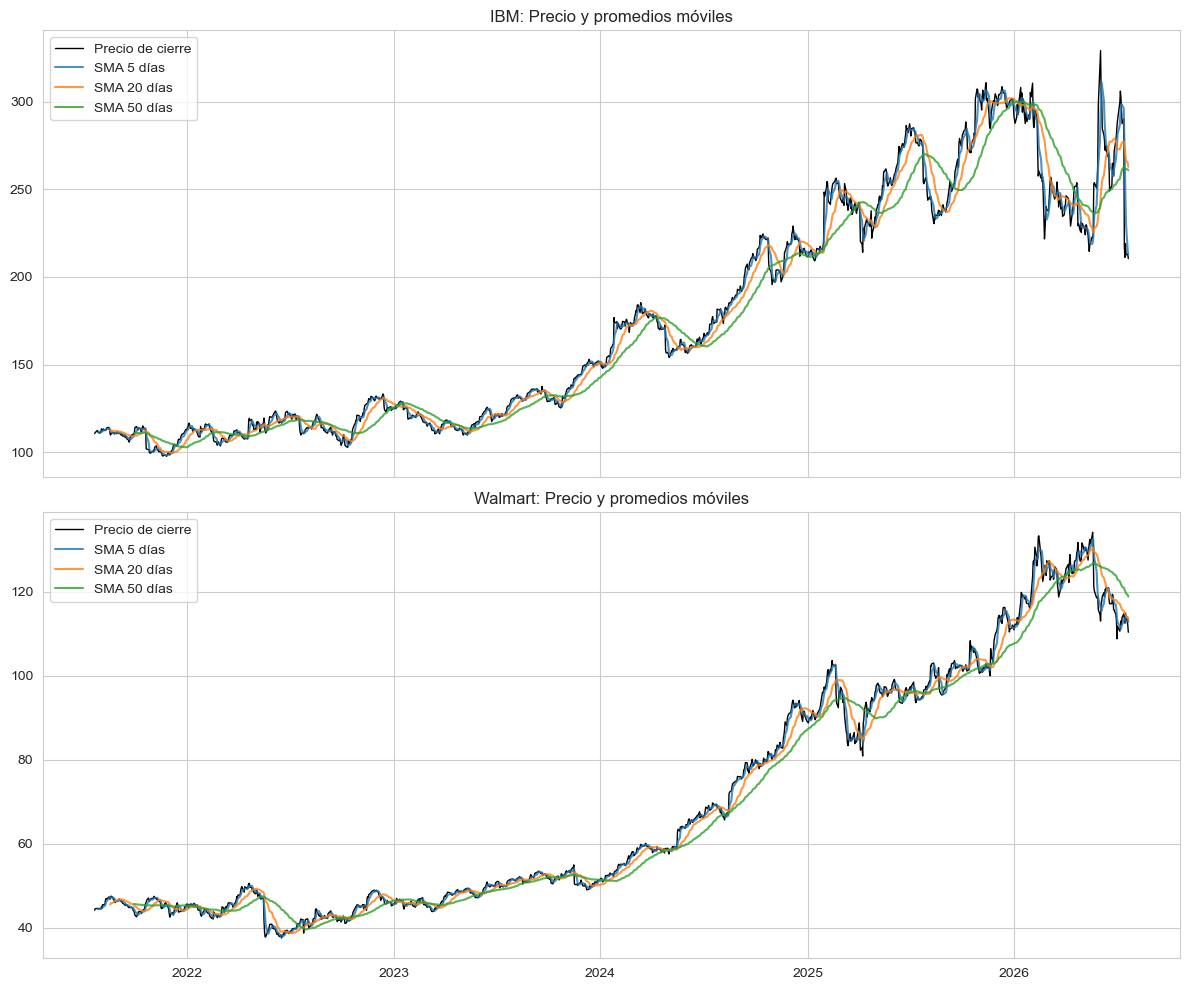

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(close.index, close["IBM"], label="Precio de cierre", color="black", linewidth=1)
axes[0].plot(close.index, close["IBM_SMA5"], label="SMA 5 días", alpha=0.8)
axes[0].plot(close.index, close["IBM_SMA20"], label="SMA 20 días", alpha=0.8)
axes[0].plot(close.index, close["IBM_SMA50"], label="SMA 50 días", alpha=0.8)
axes[0].set_title("IBM: Precio y promedios móviles")
axes[0].legend()

axes[1].plot(close.index, close["WMT"], label="Precio de cierre", color="black", linewidth=1)
axes[1].plot(close.index, close["WMT_SMA5"], label="SMA 5 días", alpha=0.8)
axes[1].plot(close.index, close["WMT_SMA20"], label="SMA 20 días", alpha=0.8)
axes[1].plot(close.index, close["WMT_SMA50"], label="SMA 50 días", alpha=0.8)
axes[1].set_title("Walmart: Precio y promedios móviles")
axes[1].legend()

plt.tight_layout()
plt.show()

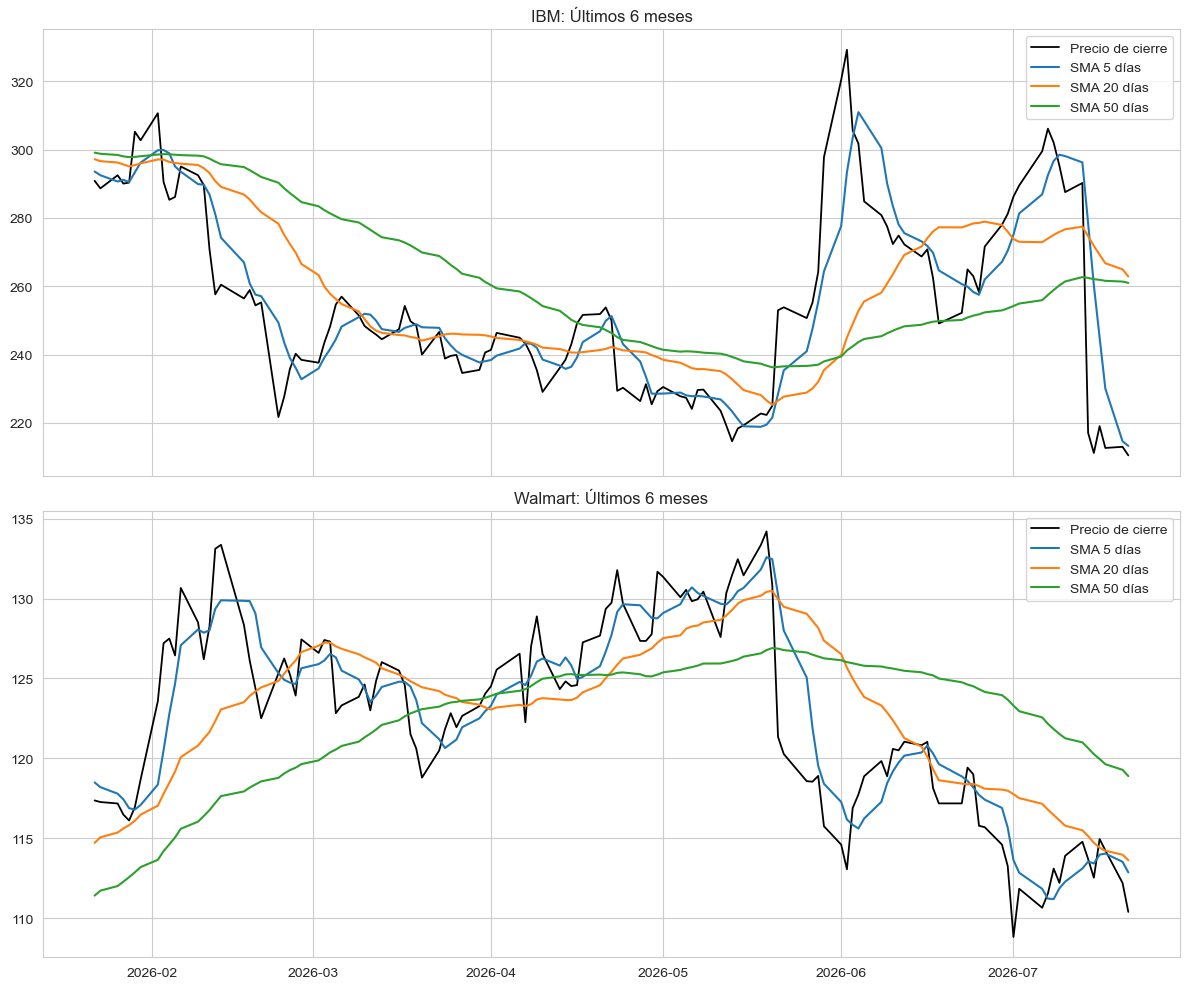

In [49]:
# Zoom a los últimos 6 meses para apreciar mejor la relación entre el precio y las SMA de corto plazo
ultimos_meses = close.loc[(close.index.max() - pd.Timedelta("180D")):close.index.max()]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(ultimos_meses.index, ultimos_meses["IBM"], label="Precio de cierre", color="black", linewidth=1.3)
axes[0].plot(ultimos_meses.index, ultimos_meses["IBM_SMA5"], label="SMA 5 días")
axes[0].plot(ultimos_meses.index, ultimos_meses["IBM_SMA20"], label="SMA 20 días")
axes[0].plot(ultimos_meses.index, ultimos_meses["IBM_SMA50"], label="SMA 50 días")
axes[0].set_title("IBM: Últimos 6 meses")
axes[0].legend()

axes[1].plot(ultimos_meses.index, ultimos_meses["WMT"], label="Precio de cierre", color="black", linewidth=1.3)
axes[1].plot(ultimos_meses.index, ultimos_meses["WMT_SMA5"], label="SMA 5 días")
axes[1].plot(ultimos_meses.index, ultimos_meses["WMT_SMA20"], label="SMA 20 días")
axes[1].plot(ultimos_meses.index, ultimos_meses["WMT_SMA50"], label="SMA 50 días")
axes[1].set_title("Walmart: Últimos 6 meses")
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.2 Pronóstico ingenuo del siguiente día con promedio móvil

El método de pronóstico por promedios móviles más simple consiste en usar el último valor del promedio móvil disponible como pronóstico del precio del día siguiente:

$$\hat{P}_{t+1} = SMA_n(t)$$

Se calcula este pronóstico para ambas empresas usando la ventana de 5 días (la más reactiva a cambios recientes).

In [62]:
# Pronóstico puntual del siguiente día (SMA 5)
ultimo_precio = close[["IBM", "WMT"]].iloc[-1]
pronostico_sma5 = close[["IBM_SMA5", "WMT_SMA5"]].iloc[-1]

resumen_pronostico = pd.DataFrame({
    "Último precio observado": ultimo_precio.values,
    "Pronóstico siguiente día (SMA 5)": pronostico_sma5.values
}, index=["IBM", "WMT"])

resumen_pronostico["Diferencia (%)"] = (
    (resumen_pronostico["Pronóstico siguiente día (SMA 5)"] - resumen_pronostico["Último precio observado"])
    / resumen_pronostico["Último precio observado"] * 100)

resumen_pronostico

,Último precio observado,Pronóstico siguiente día (SMA 5),Diferencia (%)
IBM,210.500000,213.284000,1.322565
WMT,110.389999,112.861998,2.239332


In [64]:
# Error histórico "en vivo" del método (comparando, día a día, el SMA(5) del día anterior contra el precio real observado)
for empresa in ["IBM", "WMT"]:
    pronostico_historico = close[f"{empresa}_SMA5"].shift(1)
    error_abs = (close[empresa] - pronostico_historico).abs()
    error_pct = (error_abs / close[empresa]) * 100
    print(f"{empresa}: MAE = {error_abs.mean():.3f} USD | MAPE = {error_pct.mean():.2f}%")

IBM: MAE = 3.757 USD | MAPE = 1.97%
WMT: MAE = 1.095 USD | MAPE = 1.51%


### Discusión con los resultados obtenidos para responder: ¿Esperarías que dichos pronósticos sean buenos?

A primera vista, un MAPE de 1.97% (IBM) y 1.51% (WMT) parece un desempeño bastante bueno. Sin embargo, combinando esto con todo lo que encontrado anteriormente, la respuesta es **no, no esperaría que este pronóstico sea realmente bueno como herramienta predictiva**, por las siguientes razones:

1. **El bajo MAPE es producto de la volatilidad diaria pequeña, no de que el modelo "entienda" el mercado:** como se confirmó con el ADF, el precio en niveles tiene raíz unitaria (comportamiento de caminata aleatoria), o sea, el precio de un día a otro cambia relativamente poco en términos porcentuales, así que cualquier pronóstico ingenuo, incluyendo simplemente decir "mañana el precio será igual al de hoy", también obtendría un MAPE bajo similar. El SMA(5) no está aportando información real sobre hacia dónde se moverá el precio.

2. **Efecto de rezago (lag):** en la gráfica de "últimos 6 meses" se ve que el SMA(5) "persigue" al precio real en vez de anticiparlo. En los tramos donde el precio cae bruscamente (por ejemplo, la caída fuerte de IBM a finales de la serie, de ~300 a ~215 USD), el SMA(5) reacciona después, con
varios días de retraso.

3. **El pronóstico actual (+1.32% en IBM y +2.24% en WMT) no dice nada sobre la dirección real del mercado:** se confirmó con la correlación de rendimientos (r = 0.1014) y con el ACF/PACF de rendimientos que estos son prácticamente ruido blanco, es decir, no existe un patrón sistemático en el precio pasado que permita anticipar si el próximo movimiento será al alza o a la baja. El SMA(5) simplemente extrapola el nivel promedio reciente, no predice una dirección informada.

4. **No incorpora información nueva:** los verdaderos motores del movimiento diario del precio como son las noticias, los resultados trimestrales, los cambios macroeconómicos o de sentimiento de mercado, no están representados en un promedio de precios pasados.

5. **Consistente con la hipótesis de mercados eficientes:** dado que el ADF confirma estacionariedad en los rendimientos y el ACF/PACF muestra autocorrelación prácticamente nula, por definición no existe un patrón explotable de forma consistente usando solo el historial de precios, ni con SMA(5), ni con ningún otro método basado únicamente en precios pasados.

### Conclusión
El pronóstico por promedio móvil es útil como suavizador visual de tendencia (por ejemplo, para identificar hacia dónde se dirige el precio en el corto/mediano plazo, como se muestra en la gráfica de últimos 6 meses), pero no debe interpretarse como un pronóstico confiable del valor exacto del precio del día siguiente. Su bajo error aparente (MAPE ~1.5-2%) es un reflejo de la baja volatilidad diaria de las acciones, no de una capacidad predictiva genuina del modelo. Para pronósticos más robustos habría que recurrir a modelos que sí modelen explícitamente la estructura estocástica de la serie (por ejemplo, ARIMA sobre los rendimientos, que ya se confirmaron como estacionarios), o incorporar variables exógenas relevantes (mercado general, tasas de interés, resultados financieros, sentimiento de noticias, etc.).